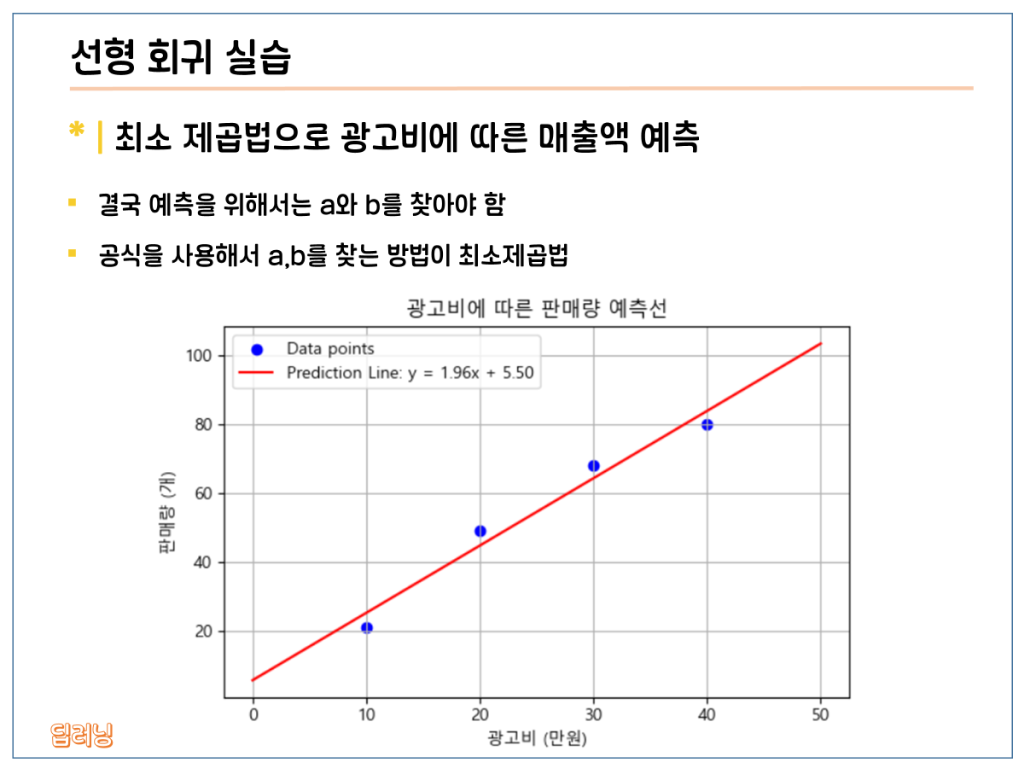

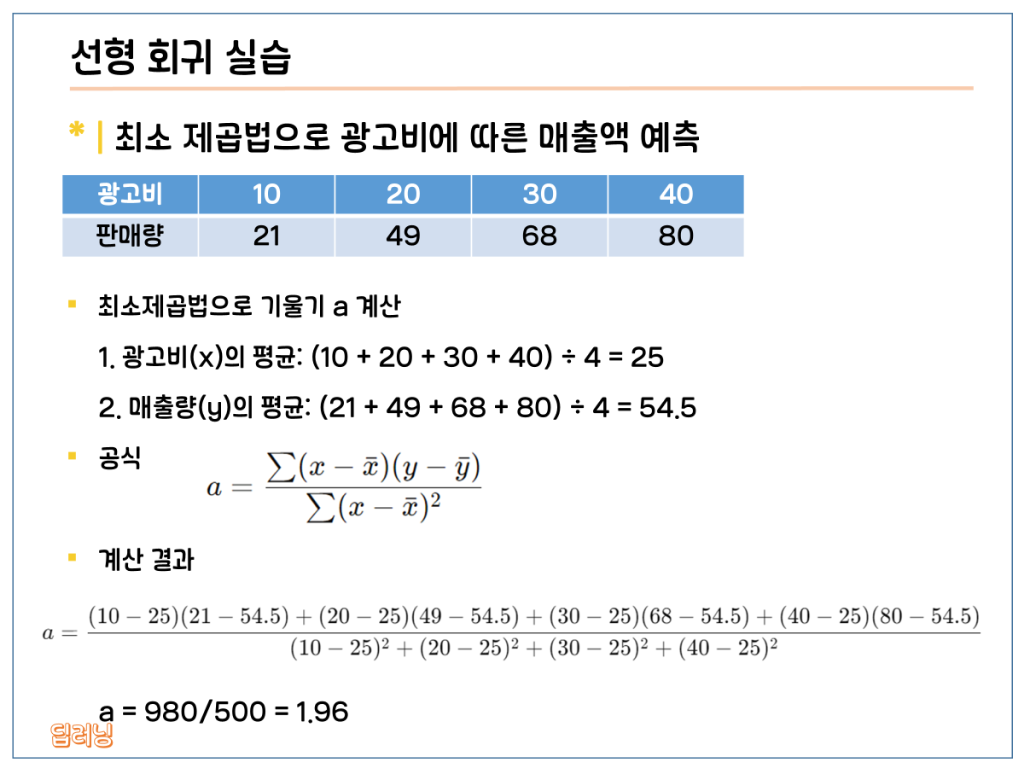

In [ ]:
x1 = 10
x2 = 20
x3 = 30
x4 = 40

<details>
<summary>공식에 대한 chatgpt 설명</summary>

[현재 서울 날짜 및 시각 2026-09-17 21:21:07]

좋아. 이건 **“왜 선형회귀식의 기울기와 절편 공식이 저 형태가 되는가?”**를 이해하면 최소제곱법이 거의 다 정리돼.

핵심부터 말하면,

> **최소제곱법(Least Squares)은 관측값과 회귀선 사이의 세로 거리인 잔차(residual)를 제곱해서 모두 더한 값이 가장 작아지도록 직선을 고르는 방법**이야.

즉, 우리가 먼저 “오차 제곱합을 최소화하자”라는 목적함수를 정하고, 그 목적함수를 미분해서 최소가 되는 \(b_0,b_1\)을 찾으면 익숙한 회귀계수 공식이 자연스럽게 나온다.

genui{"learning_viz":{"type_id":"LEAST_SQUARE_REGRESSION","locale_override":"ko-KR"}}

---

# 1. 먼저 우리가 구하려는 것은 무엇인가?

데이터가 다음처럼 있다고 하자.

$$
(x_1,y_1), (x_2,y_2),\cdots,(x_n,y_n)
$$

우리는 이 데이터들을 가장 잘 설명하는 직선

$$
\hat y=b_0+b_1x
$$

을 찾고 싶다.

여기서

$$
b_0=\text{절편(intercept)}
$$

$$
b_1=\text{기울기(slope)}
$$

야.

예를 들어 공부시간 \(x\)와 시험점수 \(y\)가 있다고 하면,

$$
\hat y = 40 + 5x
$$

라는 회귀식은

> 공부시간이 1시간 증가할 때 예상 시험점수가 평균적으로 5점 증가한다.

는 뜻이지.

---

# 2. 그런데 “가장 잘 맞는 직선”을 어떻게 정의할까?

여기서부터 최소제곱법의 핵심이 시작된다.

각 실제 관측값은

$$
y_i
$$

이고 회귀선이 예측한 값은

$$
\hat y_i=b_0+b_1x_i
$$

다.

그러므로 두 값의 차이

$$
e_i = y_i-\hat y_i
$$

를 **잔차(residual)**라고 한다.

즉,

$$
e_i
=
y_i-(b_0+b_1x_i)
$$

이다.

그림으로 보면

```text
y

│                ● 실제값 yi
│                │
│                │ residual
│                │
│-------------- × 예측값 ŷi
│             /
│           /   회귀선
│         /
│
└──────────────────── x
               xi
```

우리가 원하는 건 이 세로 거리들이 전체적으로 작아지는 직선이다.

---

# 3. 그런데 왜 그냥 잔차를 더하면 안 될까?

예를 들어 잔차가

$$
+3,\quad -3
$$

이라고 하자.

그냥 더하면

$$
3+(-3)=0
$$

이다.

그렇다고 완벽한 회귀선은 아니지.

실제로 두 점 모두 회귀선에서 3만큼 떨어져 있다.

그래서 절댓값을 사용할 수도 있다.

$$
|e_1|+|e_2|+\cdots
$$

실제로 이런 방법도 있고, **L1 regression / Least Absolute Deviations**라고 한다.

하지만 전통적인 선형회귀에서는

$$
e_i^2
$$

를 사용한다.

그래서 목적함수가

$$
SSE
=
\sum_{i=1}^{n}e_i^2
$$

가 된다.

즉,

$$
SSE
=
\sum_{i=1}^{n}
\left[y_i-(b_0+b_1x_i)\right]^2
$$

이다.

이게 바로 **Residual Sum of Squares(RSS)** 또는 **Sum of Squared Errors(SSE)**다.

---

# 4. 이제 문제는 수학적으로 이렇게 바뀐다

우리가 찾고 싶은 것은

$$
b_0,\ b_1
$$

인데,

$$
SSE(b_0,b_1)
=
\sum
[y_i-b_0-b_1x_i]^2
$$

를 **최소화하는 \(b_0,b_1\)**를 찾으면 된다.

즉 최적화 문제다.

$$
\min_{b_0,b_1}
\sum_{i=1}^{n}
(y_i-b_0-b_1x_i)^2
$$

여기까지 이해하면 최소제곱법의 논리는 이미 절반 이상 이해한 거야.

---

# 5. 최소값을 어떻게 찾는가?

미적분에서 함수

$$
f(x)=x^2
$$

의 최소값을 찾으려면 미분해서

$$
f'(x)=0
$$

이 되는 지점을 찾는다.

같은 원리를 사용한다.

이번에는 변수가 두 개니까

$$
b_0,\quad b_1
$$

각각에 대해 **편미분(partial derivative)**한다.

---

# 6. 먼저 \(b_0\)에 대해 미분해보자

목적함수는

$$
SSE
=
\sum
(y_i-b_0-b_1x_i)^2
$$

이다.

\(b_0\)으로 미분하면

$$
\frac{\partial SSE}{\partial b_0}
=
-2\sum
(y_i-b_0-b_1x_i)
$$

이다.

최솟값에서는 이것이 0이다.

따라서

$$
-2\sum
(y_i-b_0-b_1x_i)=0
$$

즉,

$$
\sum(y_i-b_0-b_1x_i)=0
$$

이 된다.

전개하면

$$
\sum y_i
-
nb_0
-
b_1\sum x_i
=
0
$$

이다.

양변을 \(n\)으로 나누면

$$
\frac{\sum y_i}{n}
-
b_0
-
b_1\frac{\sum x_i}{n}
=0
$$

이다.

여기서

$$
\bar y=\frac{\sum y_i}{n}
$$

이고

$$
\bar x=\frac{\sum x_i}{n}
$$

이므로,

$$
\bar y-b_0-b_1\bar x=0
$$

따라서

$$
\boxed{
b_0=\bar y-b_1\bar x
}
$$

가 나온다.

이게 우리가 외우던 **절편 공식**이다.

---

# 7. 이 식에는 매우 중요한 의미가 있다

방금 식을 정리하면

$$
\bar y
=
b_0+b_1\bar x
$$

이다.

그런데 회귀식이

$$
\hat y=b_0+b_1x
$$

였지.

따라서 \(x=\bar x\)를 넣으면

$$
\hat y=\bar y
$$

가 된다.

즉,

> **최소제곱 회귀선은 반드시 데이터의 중심점**

$$
(\bar x,\bar y)
$$

을 지난다.

이건 단순 암기사항이 아니라 방금 최소제곱 조건에서 직접 나온 결과야.

---

# 8. 이제 \(b_1\)에 대해 미분한다

다시 목적함수:

$$
SSE
=
\sum
(y_i-b_0-b_1x_i)^2
$$

이번에는 \(b_1\)으로 편미분한다.

$$
\frac{\partial SSE}{\partial b_1}
=
-2\sum
x_i(y_i-b_0-b_1x_i)
$$

최솟값이므로

$$
-2\sum
x_i(y_i-b_0-b_1x_i)=0
$$

따라서

$$
\sum
x_i(y_i-b_0-b_1x_i)=0
$$

이다.

전개하면

$$
\sum x_iy_i
-
b_0\sum x_i
-
b_1\sum x_i^2
=0
$$

이다.

그리고 아까 얻은

$$
b_0=\bar y-b_1\bar x
$$

를 여기에 대입한다.

정리하면 최종적으로

$$
\boxed{
b_1
=
\frac{
\sum (x_i-\bar x)(y_i-\bar y)
}{
\sum (x_i-\bar x)^2
}
}
$$

가 나온다.

이게 단순선형회귀의 기울기 공식이다.

---

# 9. 이 공식을 해석하면 훨씬 이해하기 쉽다

기울기는

$$
b_1
=
\frac{
\sum (x_i-\bar x)(y_i-\bar y)
}{
\sum (x_i-\bar x)^2
}
$$

이다.

분자는

$$
\sum (x_i-\bar x)(y_i-\bar y)
$$

인데, 이건 \(x\)와 \(y\)가 **같은 방향으로 움직이는 정도**다.

공분산(covariance)의 핵심 부분이지.

반면 분모는

$$
\sum (x_i-\bar x)^2
$$

인데, 이건 \(x\) 자체가 얼마나 퍼져 있는지를 나타낸다.

분산(variance)의 핵심 부분이다.

그래서 개념적으로는

$$
\boxed{
b_1
=
\frac{\text{x와 y가 함께 움직이는 정도}}
{\text{x 자체가 움직이는 정도}}
}
$$

라고 이해하면 된다.

---

# 10. 그래서 흔히 이런 형태로도 쓴다

표본 공분산을

$$
Cov(X,Y)
$$

분산을

$$
Var(X)
$$

라고 하면

$$
\boxed{
b_1
=
\frac{Cov(X,Y)}
{Var(X)}
}
$$

이다.

이 표현이 매우 중요하다.

왜냐하면 기울기가 결국

> **X가 변할 때 Y가 얼마나 함께 변하는지를 X의 변동성으로 나눈 것**

이라는 의미를 바로 보여주기 때문이다.

---

# 11. 숫자로 직접 보면 더 명확하다

예를 들어 세 학생이 있다고 하자.

| 공부시간 \(x\) | 시험점수 \(y\) |
| ---------: | ---------: |
|          1 |         50 |
|          2 |         60 |
|          3 |         70 |

평균은

$$
\bar x=2
$$

$$
\bar y=60
$$

이다.

각 값에서 평균을 빼보자.

|  x |  y | \(x-\bar x\) | \(y-\bar y\) |
| -: | -: | -----------: | -----------: |
|  1 | 50 |           -1 |          -10 |
|  2 | 60 |            0 |            0 |
|  3 | 70 |            1 |           10 |

기울기의 분자는

$$
(-1)(-10)+(0)(0)+(1)(10)
$$

$$
=10+0+10
$$

$$
=20
$$

이다.

분모는

$$
(-1)^2+0^2+1^2
$$

$$
=2
$$

이다.

따라서

$$
b_1=\frac{20}{2}=10
$$

이다.

절편은

$$
b_0=\bar y-b_1\bar x
$$

이므로

$$
=60-10(2)
$$

$$
=40
$$

이다.

따라서 회귀선은

$$
\boxed{
\hat y=40+10x
}
$$

이다.

실제로

$$
x=1\Rightarrow y=50
$$

$$
x=2\Rightarrow y=60
$$

$$
x=3\Rightarrow y=70
$$

이므로 세 점을 정확히 통과한다.

---

# 12. 최소제곱법의 더 깊은 의미: 잔차와 직선의 관계

아까 \(b_0\) 미분 결과가

$$
\sum e_i=0
$$

이었다.

즉 최소제곱 회귀에서는

$$
\boxed{
\sum residual=0
}
$$

이다.

양의 오차와 음의 오차가 균형을 이룬다.

그리고 \(b_1\) 미분 결과에서는

$$
\sum x_i e_i=0
$$

이 나온다.

즉,

$$
\boxed{
\sum x_i residual_i=0
}
$$

이다.

이건 잔차가 설명변수 \(X\)와 직교(orthogonal)한다는 의미다.

여기서 선형대수적인 해석이 나온다.

---

# 13. 선형대수에서 보면 최소제곱법은 “투영(projection)”이다

다중선형회귀에서는

$$
y=X\beta+\epsilon
$$

라고 쓴다.

최소제곱법은

$$
\|y-X\beta\|^2
$$

를 최소화한다.

미분하면

$$
X^T(y-X\beta)=0
$$

이 되고,

$$
X^TX\beta=X^Ty
$$

가 된다.

이를 **정규방정식(normal equation)**이라고 한다.

따라서

$$
\boxed{
\hat\beta
=
(X^TX)^{-1}X^Ty
}
$$

가 된다.

이게 단순선형회귀를 여러 변수로 확장한 최소제곱법 공식이다.

기하학적으로는 실제 \(y\) 벡터를 \(X\)가 만드는 공간에 **가장 가까운 점으로 투영하는 것**이다.

즉 회귀는 단순히 “선을 대충 그리는 것”이 아니라,

> **관측값 벡터를 설명변수 공간에 직교투영하는 연산**

이라고 이해할 수 있어.

---

# 14. 그런데 왜 하필 “제곱”을 쓰는가?

여기에는 몇 가지 이유가 있다.

가장 직접적인 이유는 양수/음수 오차가 상쇄되지 않도록 만드는 것이다.

$$
(+5)^2=25
$$

$$
(-5)^2=25
$$

이니까 방향에 관계없이 오차 크기를 반영한다.

두 번째는 큰 오차를 더 강하게 벌점 준다는 점이다.

예를 들어 오차가

$$
1,\quad 4
$$

이면 절댓값에서는

$$
1,\quad 4
$$

지만 제곱하면

$$
1,\quad16
$$

이다.

따라서 큰 오차 하나가 훨씬 큰 영향을 준다.

세 번째는 수학적으로 다루기가 매우 편하다는 점이다.

$$
e^2
$$

는 미분 가능하고 볼록(convex)한 함수이기 때문에 최솟값을 안정적으로 찾을 수 있다.

---

# 15. 확률론적으로도 근거가 있다

여기서 더 중요한 연결이 하나 있다.

선형회귀를

$$
Y_i
=
\beta_0+\beta_1X_i+\epsilon_i
$$

라고 하고 오차가

$$
\epsilon_i\sim N(0,\sigma^2)
$$

즉 정규분포한다고 가정하자.

그러면 데이터를 관측할 likelihood를 가장 크게 만드는

**Maximum Likelihood Estimation, MLE**

을 계산하면 결과적으로

$$
\sum
(y_i-\hat y_i)^2
$$

를 최소화하는 문제가 된다.

즉,

$$
\boxed{
\text{오차가 정규분포}
\Rightarrow
\text{MLE = 최소제곱법}
}
$$

이라는 중요한 관계가 있다.

그래서 최소제곱법은 단순히 계산 편의를 위해 만들어진 임의의 공식만은 아니다.

---

# 16. Gauss-Markov 정리와도 연결된다

고전적 선형회귀의 몇 가지 조건이 만족되면 최소제곱추정량 OLS는

$$
\boxed{\text{BLUE}}
$$

가 된다.

BLUE는

**Best Linear Unbiased Estimator**

즉,

> 선형이고 불편한 추정량들 중 분산이 가장 작은 추정량

이라는 뜻이다.

여기서 재미있는 점은 **정규성 가정이 없어도** Gauss-Markov 조건 아래에서는 OLS의 BLUE 성질이 성립한다는 것이다.

정규성은 주로

* t-test
* F-test
* confidence interval
* MLE 해석

등에서 추가적으로 중요해진다.

---

# 17. ADP 관점에서는 이렇게 연결해두면 좋다

최소제곱법을 그냥

$$
b_1=
\frac{\sum(x-\bar x)(y-\bar y)}
{\sum(x-\bar x)^2}
$$

라고 외우는 것보다 다음 흐름을 기억하는 게 훨씬 강하다.

```text
관측값
    ↓
회귀선으로 예측
    ↓
잔차 발생
e = y - ŷ
    ↓
잔차는 +/-라 그냥 더하면 상쇄됨
    ↓
잔차를 제곱
    ↓
SSE = Σe²
    ↓
SSE가 최소가 되는
b0, b1을 찾음
    ↓
편미분 = 0
    ↓
b0 = ȳ - b1x̄

b1 =
Σ(x-x̄)(y-ȳ)
────────────
 Σ(x-x̄)²
```

그리고 여기서 다시

```text
기울기
    ↓
X-Y 공동변동
──────────
X 자체 변동
    ↓
Cov(X,Y)
────────
 Var(X)
```

로 연결하면 된다.

---

## 결국 최소제곱법을 한 문장으로 말하면

**“가능한 모든 직선 중에서 각 데이터와 직선 사이의 세로 오차를 제곱한 총합이 가장 작은 직선을 찾는 방법이며, 그 최솟값 조건을 편미분하면 우리가 사용하는 선형회귀 기울기와 절편 공식이 나온다.”**

특히 지금 통계를 다시 공부하는 단계라면 **공식을 먼저 외우기보다 `잔차 → 제곱 → 합 → 최소화 → 미분`이라는 논리를 먼저 잡는 게 훨씬 중요해.** 이 흐름이 나중에 다중회귀, MSE, gradient descent, 신경망의 loss function까지 그대로 이어진다.

* **“최소제곱법에서 \(b_1=Cov(X,Y)/Var(X)\)가 되는 과정을 중간 대수식을 하나도 생략하지 않고 증명해줘.”**
* **“최소제곱법과 경사하강법은 같은 선형회귀 문제를 어떻게 다르게 푸는지 비교해줘.”**
* **“잔차, 오차(error), SSE, MSE, 분산, 표준오차가 서로 어떻게 다른지 하나의 예제로 연결해서 설명해줘.”**

</details>

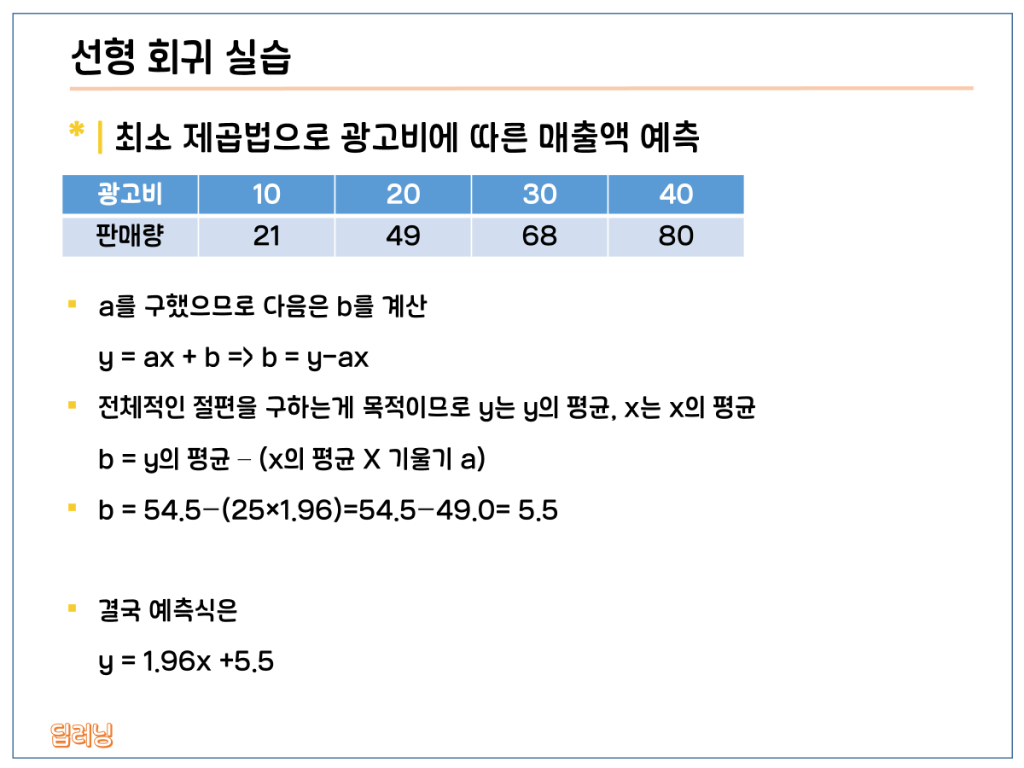

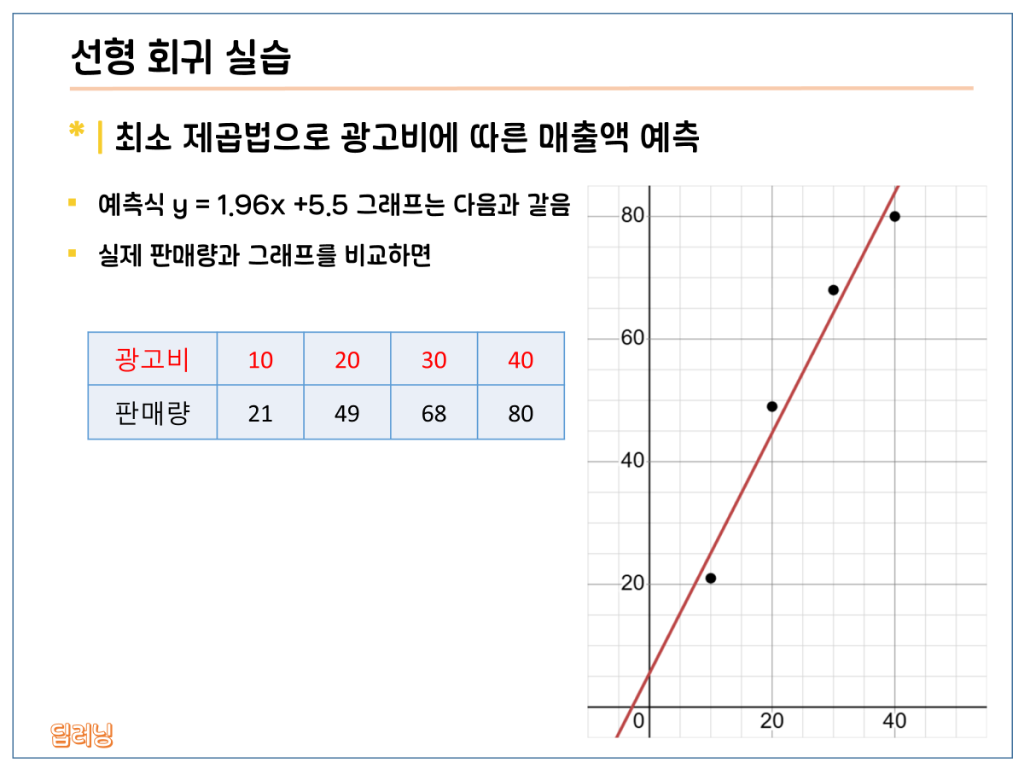

### numpy 사용한 규칙 기반 선형회귀 실습

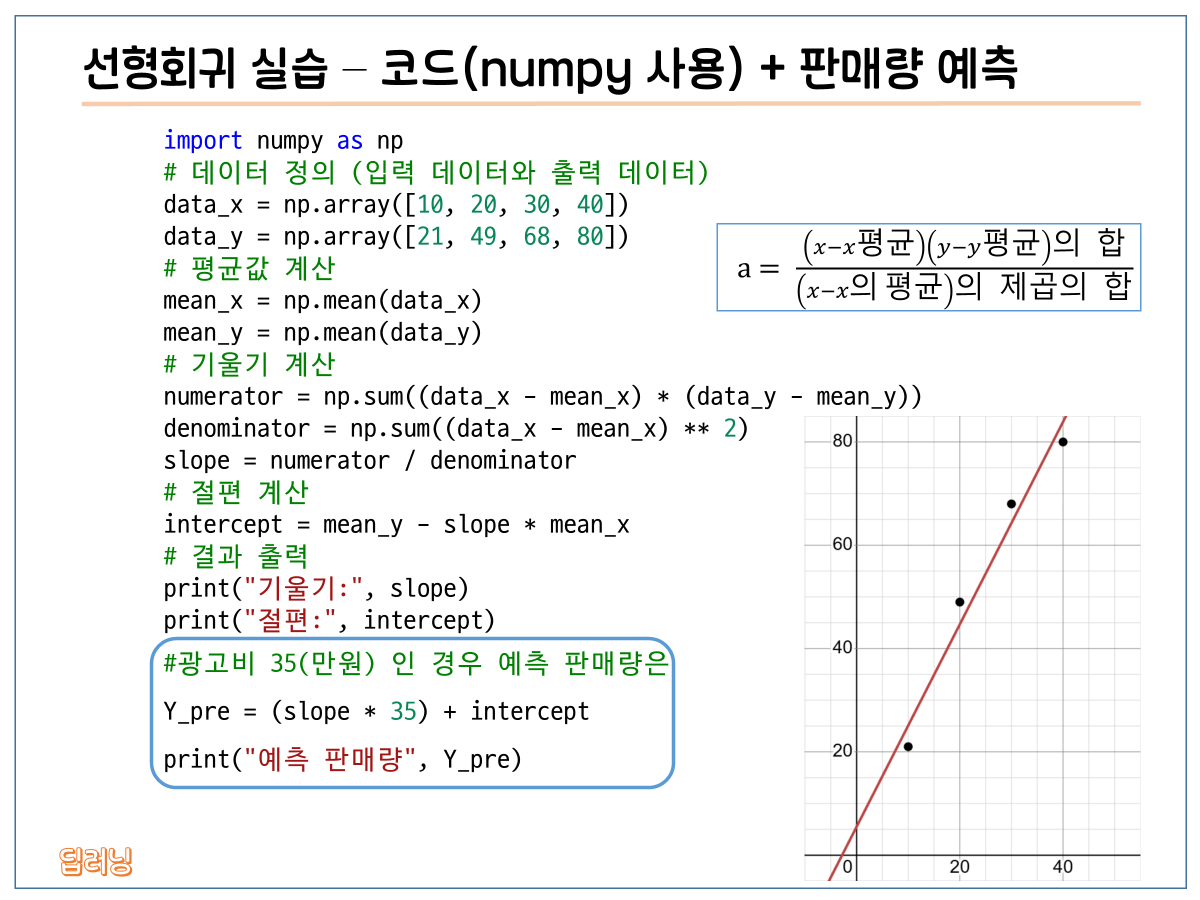

In [1]:
import numpy as np

In [2]:
# 데이터 정의 - 입/출력 데이터
data_x = np.array([10,20,30,40]) # 독립변수 -> numpy array로 만듦
data_y = np.array([21,49,68,80]) # 종속변수

# 평균 계산
mean_x = np.mean(data_x)
mean_y = np.mean(data_y)

# 기울기 계산
numerator = np.sum((data_x - mean_x) * (data_y - mean_y)) # 분자
denumerator = np.sum((data_x - mean_x) ** 2) # 분모, numpy vector 연산
slope = numerator / denumerator

# 절편 계산
intercept = mean_y - slope * mean_x

# 결과 출력
print("기울기: ", slope)
print("절편: ", intercept)

기울기:  1.96
절편:  5.5


In [10]:
# 예측 예시
x = 35
y_hat_35 = slope * x + intercept
print(f"광고비가 {x}이면 판매량은 {y_hat_35}으로 예측됩니다")

data_y_hat = data_x * slope + intercept
print(f"실제 값 {data_y} vs 선형회귀선에 따른 예측 값 {data_y_hat}")

광고비가 35이면 판매량은 74.1으로 예측됩니다
실제 값 [21 49 68 80] vs 선형회귀선에 따른 예측 값 [25.1 44.7 64.3 83.9]


In [9]:
# 강사님 예측 코드
Y_pre = (slope * 35) + intercept
print("예측 판매량: ", Y_pre)

예측 판매량:  74.1


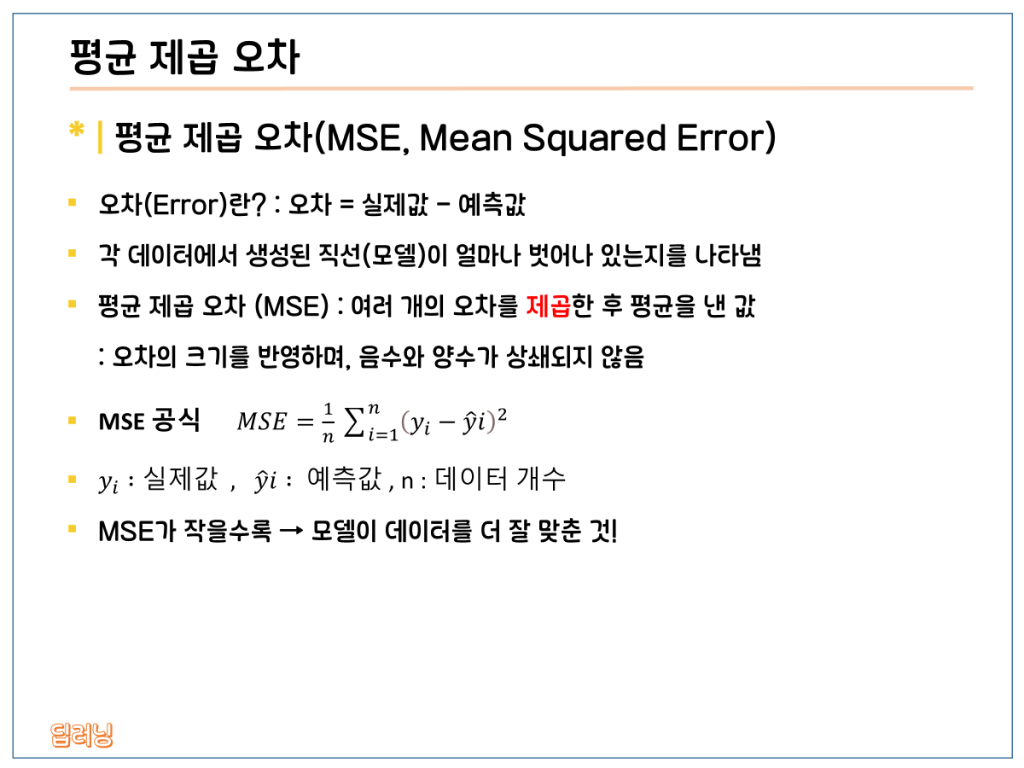

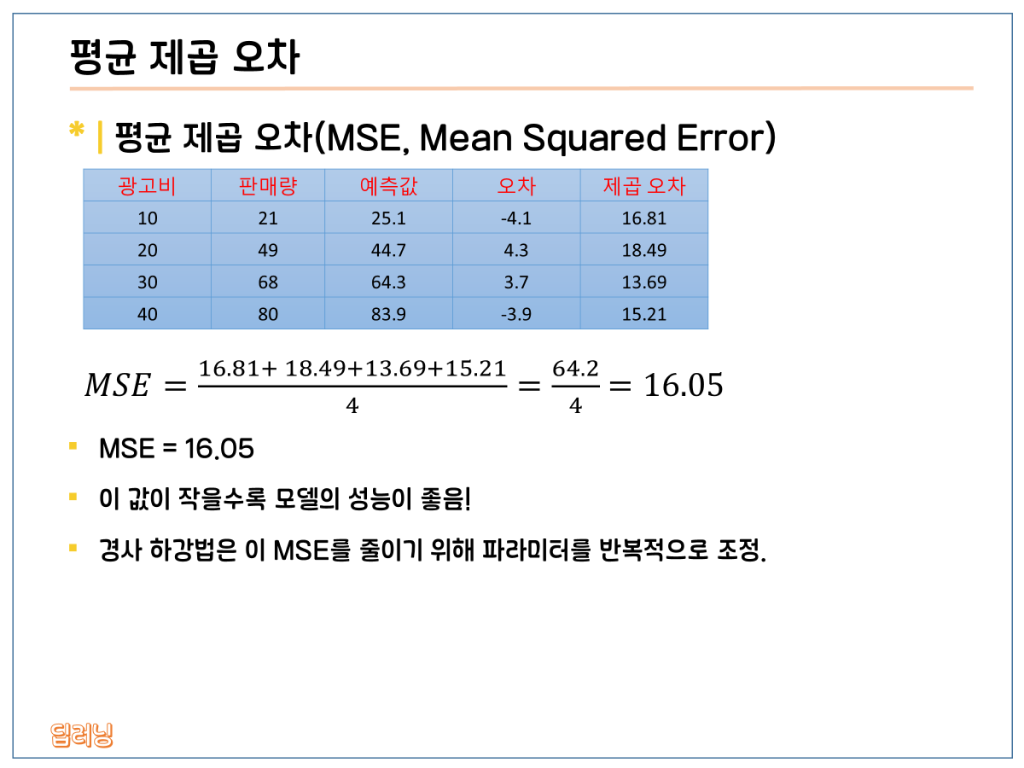

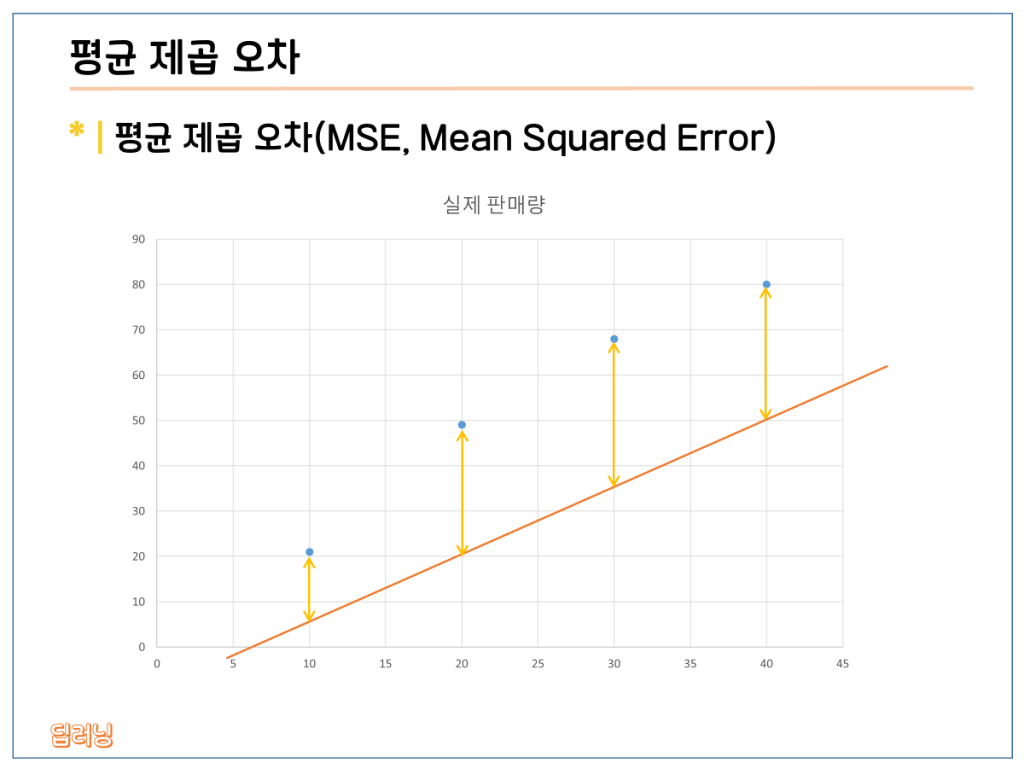

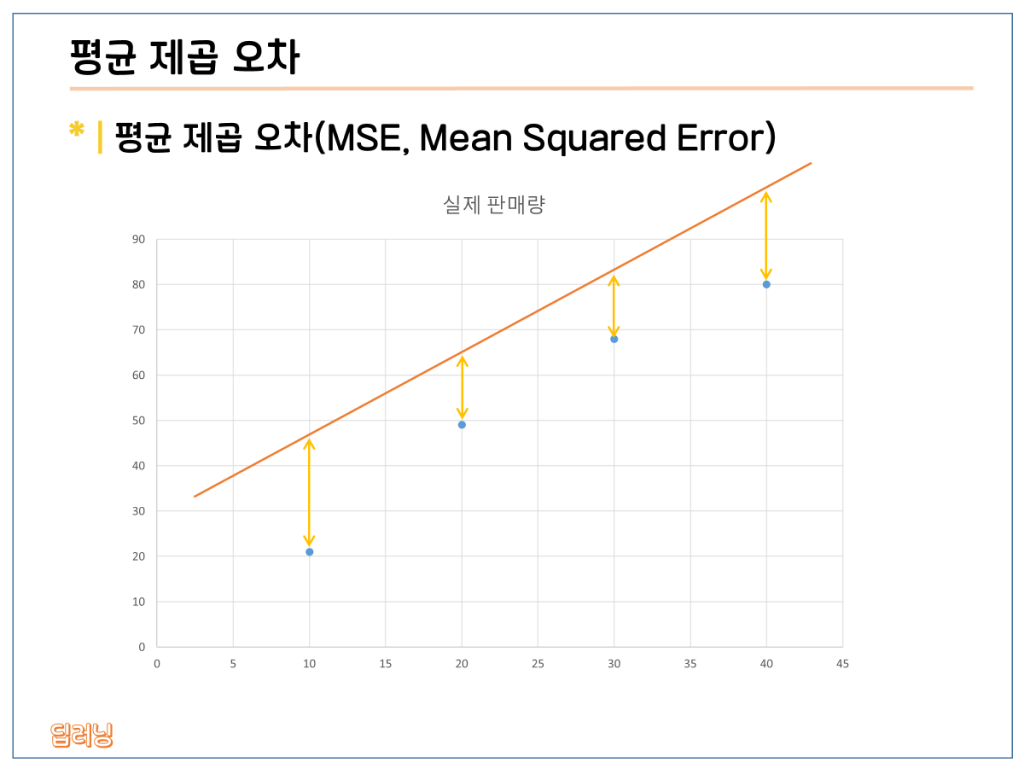

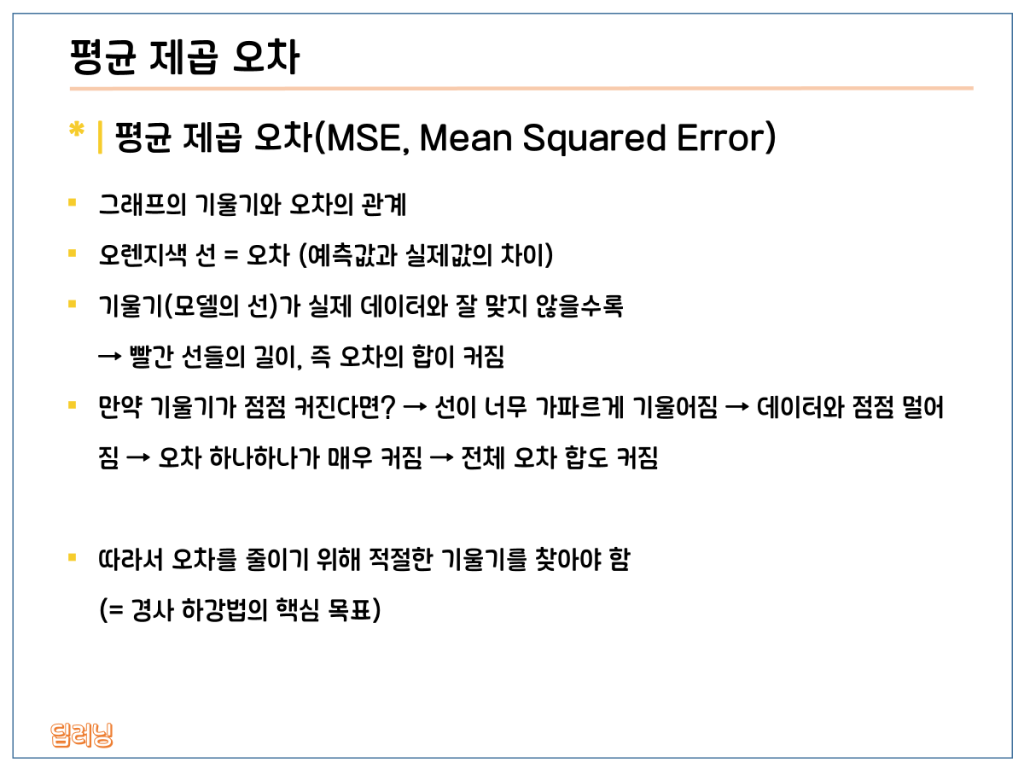

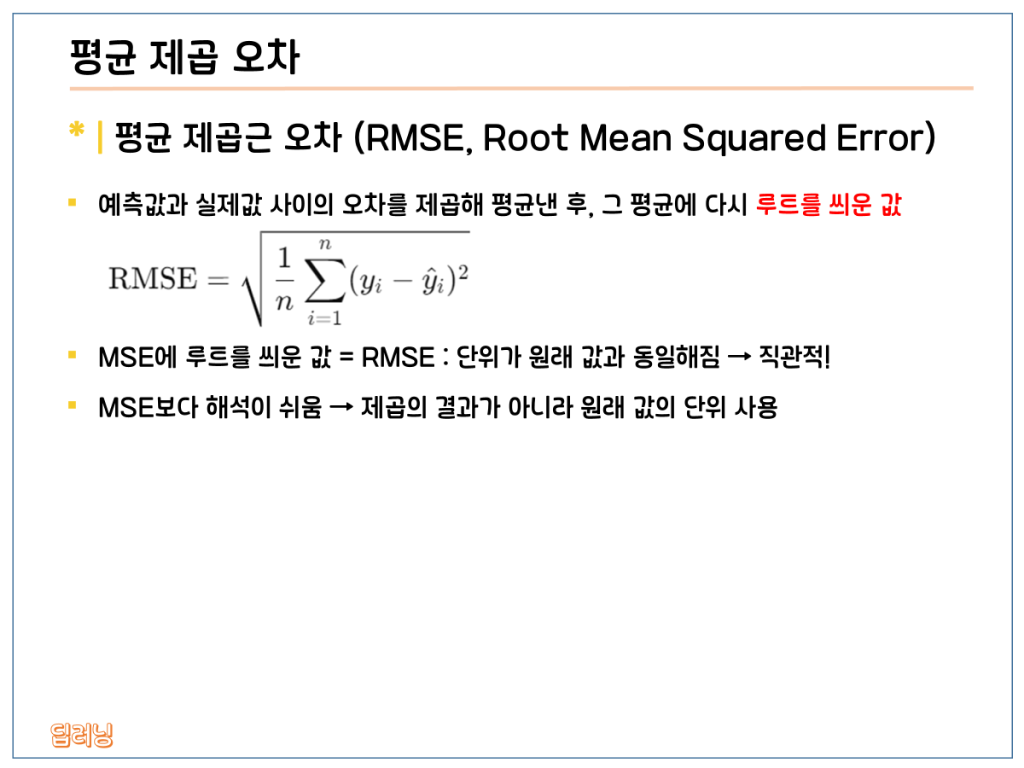

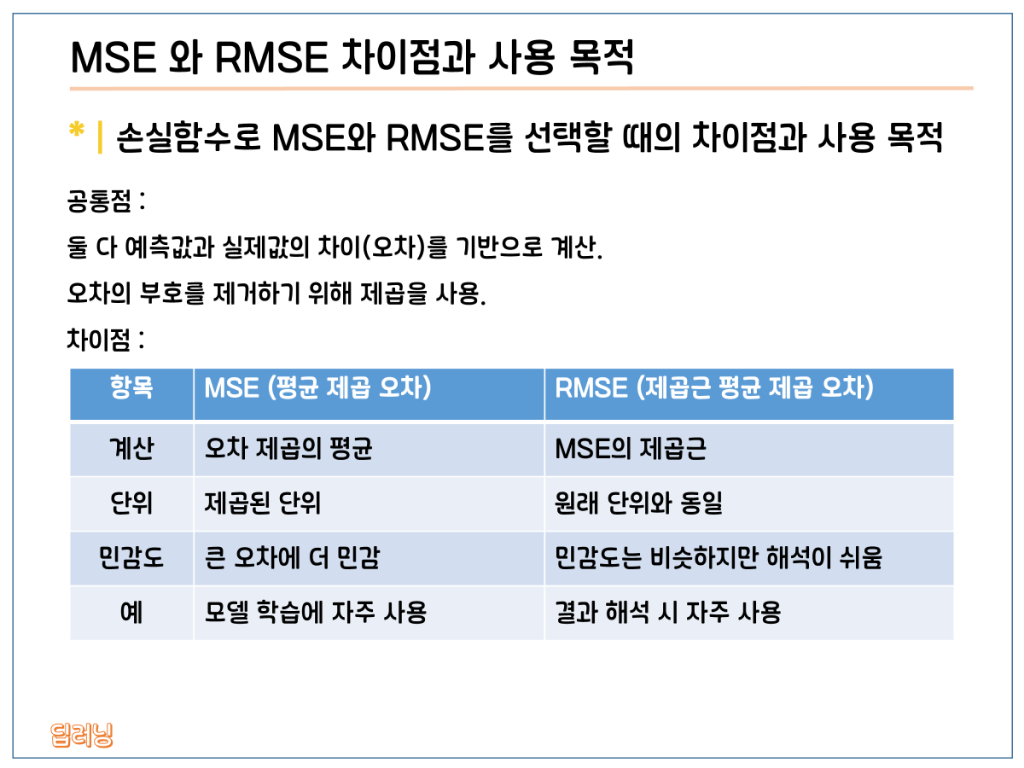

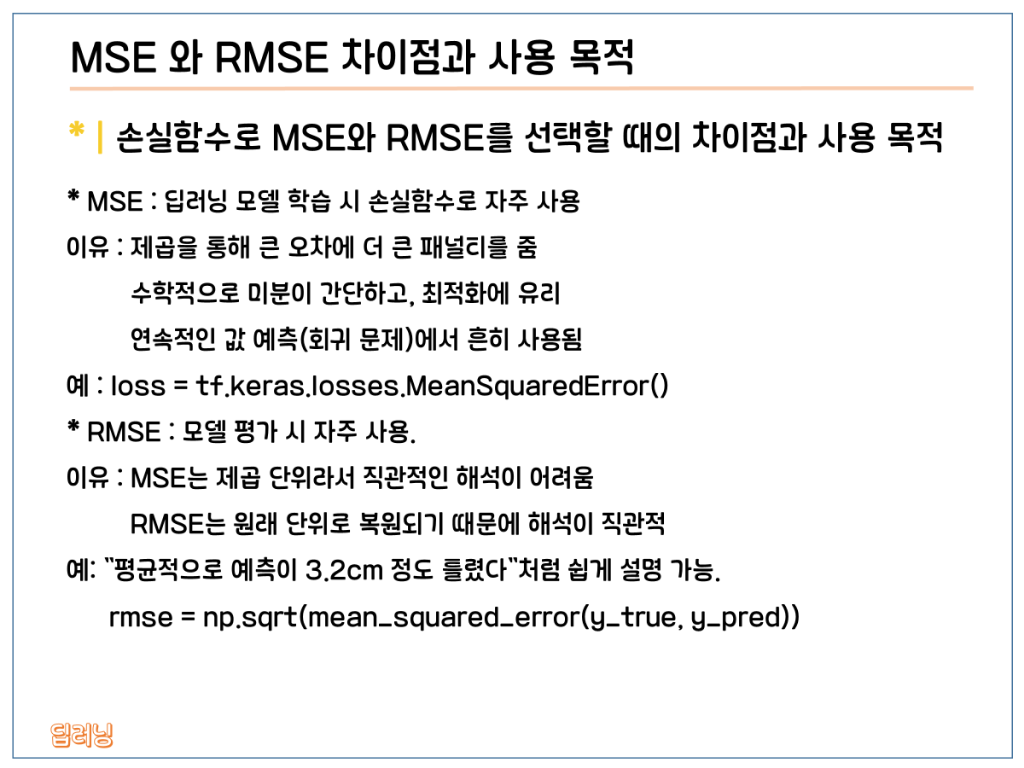

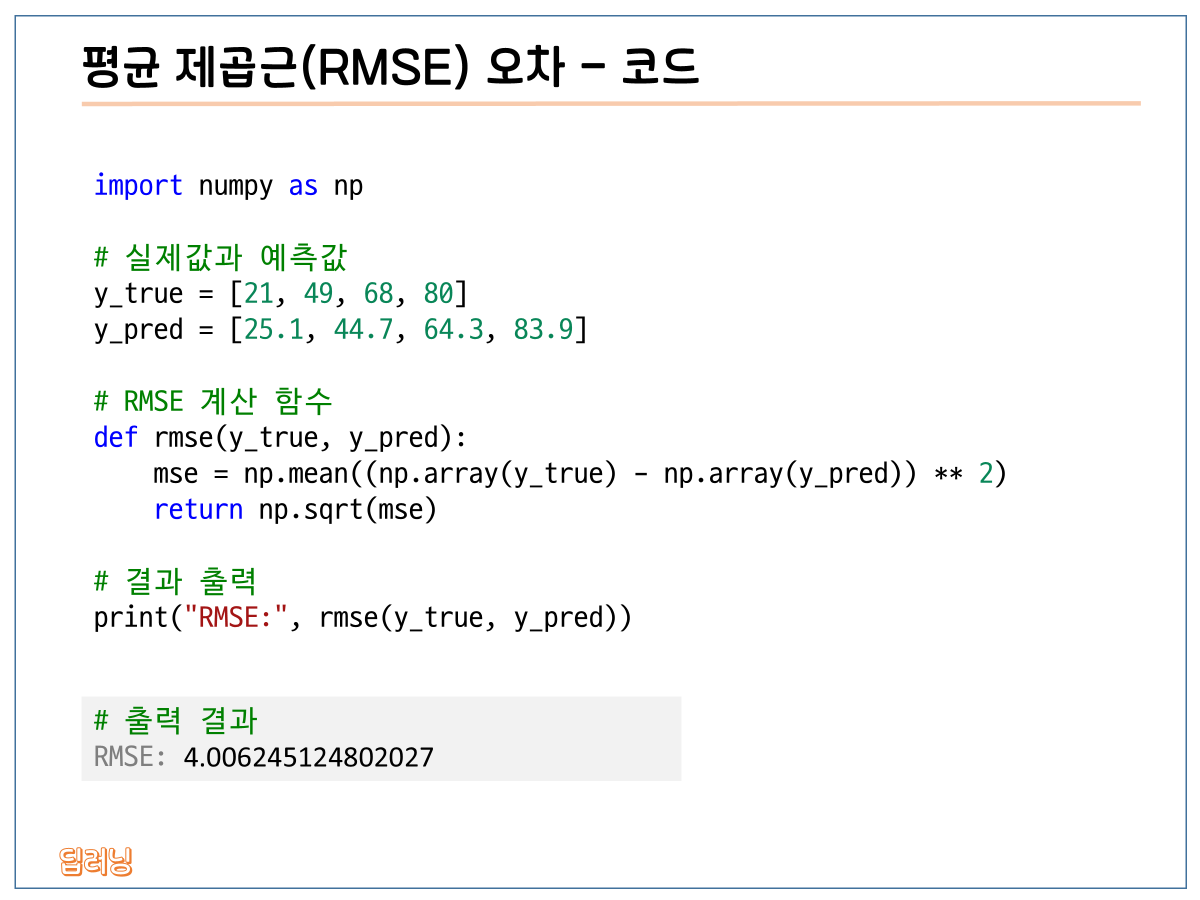

In [13]:
# 실제 값과 예측 값
y_true = [21, 49, 68, 80]
y_pred = [25.1, 44.7, 64.3, 83.9]

# RMSE(root mean square error) 계산 함수
def rmse(y_true, y_pred):
    mse = np.mean((np.array(y_true) - np.array(y_pred)) ** 2)
    return np.sqrt(mse), mse

# 매개변수 2개 전달하며 함수 호출 및 결과 출력
# print("RMSE: ", rmse(y_true, y_pred))
rmse, mse = rmse(y_true, y_pred)
print(f"MSE: {mse}, RMSE: {rmse}")

MSE: 16.05000000000001, RMSE: 4.006245124802027


오차가 가장 작아지는 지점의 파라미터를 찾는 것 = deep learning 모델링

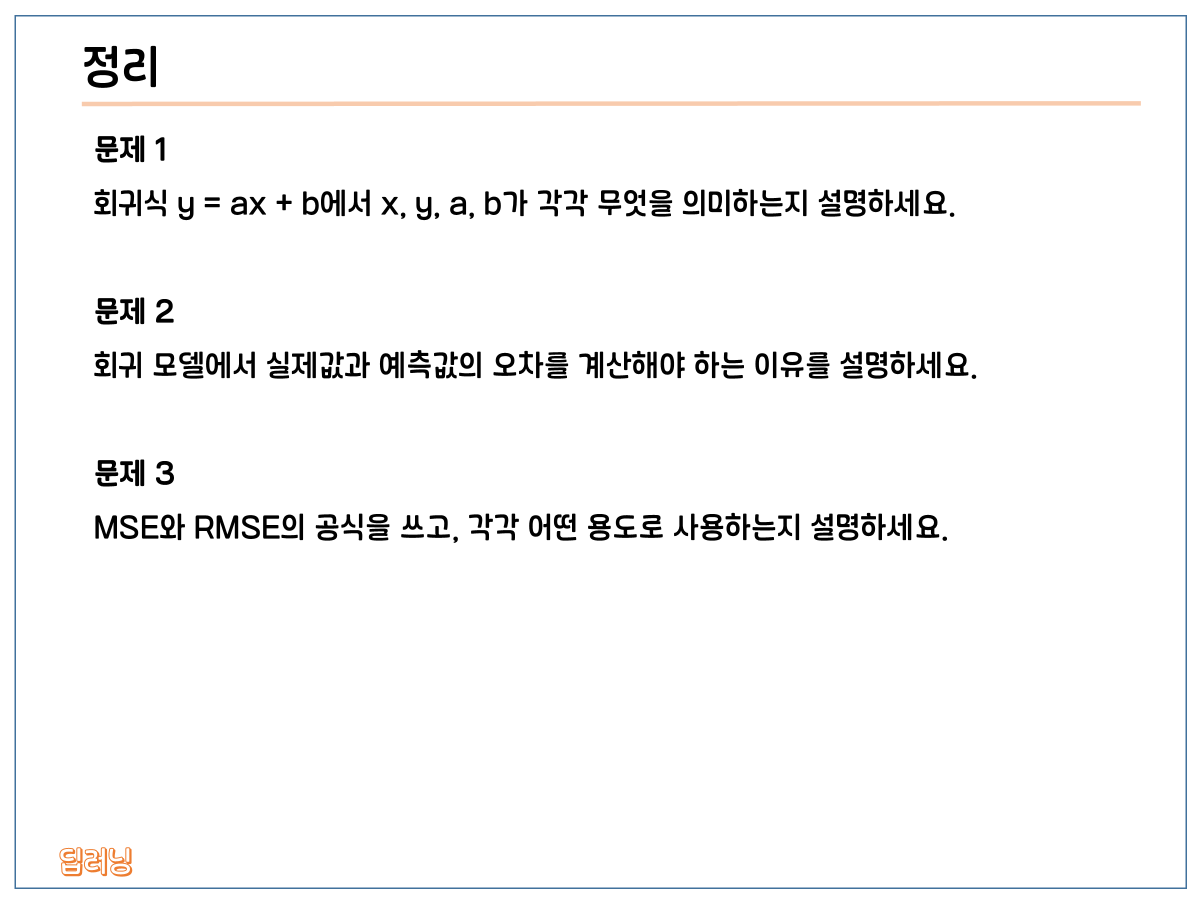

### 2026.9.17(목) 22h40 나의 답변
1. 회귀식 y = ax + b에서 x는 독립변수, y는 종속변수이며, a, b는 x와 y의 선형 관계를 설명하는 파라미터이다. a는 선형회귀선의 기울기, b는 y절편이다. 딥러닝 모델링에서? a는 weight, b는 bias의 의미를 지니게 된다.
2. 회귀 모델에서 파라미터의 데이터 설명력/표현력을 판단하기 위해 오차가 필요하다. 오차를 가장 작게 하는 파라미터를 찾는 것이 모델링의 목표이다.
3. MSE(mean squared error)는 각 관측치/실제값과 예측값의 차이의 제곱의 합의 평균이다. 오차를 제곱하는 이유는 그냥 오차를 합하면 거의 0이 되기 때문이며, 오차를 제곱하면 차이의 가시성이 향상되기도 한다. RMSE는 MSE에 제곱근을 씌운 것이다 -> MSE는 모델 학습에 vs RMSE는 결과 해석에 주로 사용한다.